Import the dataset

In [6]:
import pandas as pd

df = pd.read_csv("tested.csv")

Explore the dataset

In [ ]:
df.head()                    #First 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.shape                      #Dataset dimensions

(418, 12)

In [ ]:
df.columns                    #Column names

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [ ]:
df.info()                      #Data types

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [30]:
df.isnull().sum()                            #Missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          315
Embarked         0
dtype: int64

Handle Missing Values

In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

Convert categorical columns into numbers

In [ ]:
from sklearn.preprocessing import LabelEncoder           #Label Encoding
le = LabelEncoder()                                      #Create the encoder

In [17]:
df["Sex"] = le.fit_transform(df["Sex"])

Normalize / Standardize

In [ ]:
from sklearn.preprocessing import StandardScaler      #Standardize
scaler = StandardScaler()                             #Create object

In [20]:
df[["Age","Fare"]] = scaler.fit_transform(df[["Age","Fare"]])

Boxplot

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

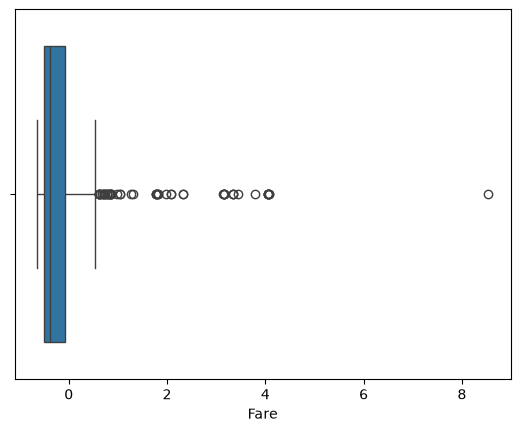

In [ ]:
sns.boxplot(x=df["Fare"])                   #Create graph
plt.show()

In [ ]:
Q1 = df["Fare"].quantile(0.25)                   #Remove outliers using IQR
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

In [ ]:
lower = Q1 - 1.5 * IQR                            #define acceptable limits
upper = Q3 + 1.5 * IQR

In [27]:
df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

In [28]:
# Save the updated dataset
df.to_csv("updated_dataset.csv", index=False)

In [29]:
print("Updated dataset saved successfully!")

Updated dataset saved successfully!
